<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part I · Foundations &nbsp;|&nbsp; Chapter 1</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">What Is Statistics? <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:680px;line-height:1.6">Five hands-on demos that turn the chapter's ideas into runnable code — descriptive statistics, the normal curve, sampling &amp; inference, the law of large numbers, and how statistics powers machine learning.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

> ### 🎯 What you'll build in this notebook
>
> | # | Demo | Concept it illustrates |
> |---|------|------------------------|
> | 1 | Exam-score summary | **Descriptive statistics** — mean, median, mode, spread |
> | 2 | The bell curve | **Normal distribution** & the 68–95–99.7 rule |
> | 3 | Population → Sample | **Inferential statistics** & the Central Limit Theorem |
> | 4 | Rolling the dice | **Law of Large Numbers** — why sampling works |
> | 5 | Experience → Salary | **Statistics → Machine Learning** (least-squares = an ML model) |

---

## ⚙️ Setup — imports & a book-matched plotting style

We define a small color palette and Matplotlib defaults so every chart in this handbook shares the same clean, modern look as the infographics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch

# Reproducible randomness
rng = np.random.default_rng(42)

# ---- Book palette (matches the HTML chapters) ----
NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"
GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"
GRID="#e6e9f2"

# ---- Global Matplotlib style ----
plt.rcParams.update({
    "figure.facecolor":"white", "axes.facecolor":"white",
    "figure.dpi":110, "savefig.dpi":110,
    "font.family":"DejaVu Sans", "font.size":11,
    "axes.edgecolor":GRID, "axes.linewidth":1.2,
    "axes.grid":True, "grid.color":GRID, "grid.linewidth":1,
    "axes.spines.top":False, "axes.spines.right":False,
    "axes.titlesize":15, "axes.titleweight":"bold", "axes.titlecolor":INK,
    "axes.labelcolor":INK_SOFT, "axes.labelsize":11.5,
    "xtick.color":INK_SOFT, "ytick.color":INK_SOFT,
    "legend.frameon":False,
})

def titlecard(ax, title, subtitle=None):
    """Add an infographic-style left-aligned title above an axis."""
    ax.set_title(title, loc="left", pad=18)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes,
                fontsize=10.5, color=INK_SOFT, va="bottom")

print("✅ Environment ready — palette loaded, RNG seeded.")

✅ Environment ready — palette loaded, RNG seeded.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · DESCRIPTIVE STATISTICS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📊 Describing a class of exam scores</div>
<div style="color:#4a5578;margin-top:6px">Descriptive statistics answers <i>"what does the data look like?"</i> — its center (mean, median, mode) and its spread (range, standard deviation).</div>
</div>

In [2]:
# Simulate exam scores for 200 students (integers, 40–100)
scores = np.clip(rng.normal(75, 11, 200).round(), 40, 100).astype(int)
data = pd.Series(scores, name="score")

mean   = data.mean()
median = data.median()
mode   = data.mode().iloc[0]
std    = data.std()

summary = pd.DataFrame({
    "Statistic":["Count","Mean","Median","Mode","Std Dev","Min","Max","Range"],
    "Value":[len(data), round(mean,1), median, mode, round(std,1),
             data.min(), data.max(), data.max()-data.min()]
})
summary

,Statistic,Value
0,Count,200.0
1,Mean,74.6
2,Median,74.0
3,Mode,71.0
4,Std Dev,9.5
5,Min,52.0
6,Max,100.0
7,Range,48.0


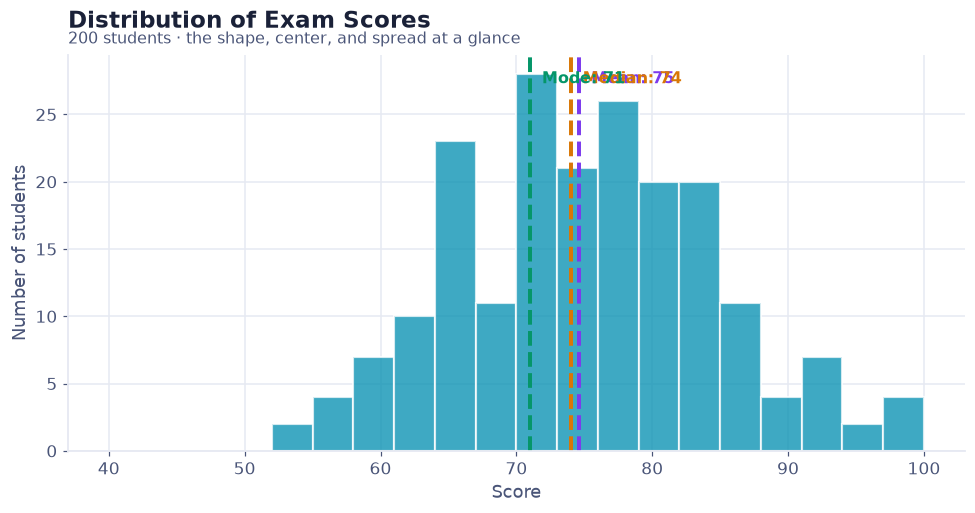

In [3]:
fig, ax = plt.subplots(figsize=(9,4.8))

n, bins, patches = ax.hist(data, bins=range(40,103,3), color=CYAN, alpha=0.78,
                           edgecolor="white", linewidth=1.4)

# Mark the three measures of central tendency
for value, label, color in [(mean,"Mean","%s"%PURPLE),
                            (median,"Median","%s"%AMBER),
                            (mode,"Mode","%s"%GREEN)]:
    ax.axvline(value, color=color, linewidth=2.6, linestyle="--")
    ax.text(value, ax.get_ylim()[1]*0.96, f"  {label}: {value:.0f}",
            color=color, fontweight="bold", fontsize=10.5, ha="left", va="top")

titlecard(ax, "Distribution of Exam Scores",
          f"200 students · the shape, center, and spread at a glance")
ax.set_xlabel("Score"); ax.set_ylabel("Number of students")
ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

**Reading the chart:** the bars show *how many* students scored in each range (the shape). The three dashed lines show the **center** three different ways. When mean ≈ median ≈ mode, the distribution is roughly **symmetric** — a hint of the *normal distribution* we explore next.

<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · THE NORMAL DISTRIBUTION</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔔 The bell curve &amp; the 68–95–99.7 rule</div>
<div style="color:#4a5578;margin-top:6px">The most important shape in all of statistics. The <b>empirical rule</b> tells us how data clusters around the mean — the backbone of confidence intervals, z-scores, and countless ML methods.</div>
</div>

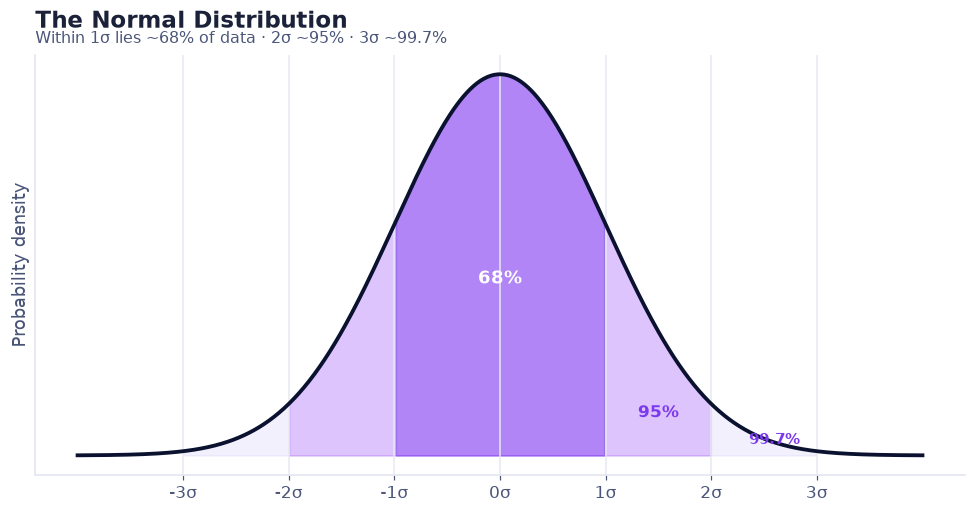

In [4]:
def normal_pdf(x, mu=0, sigma=1):
    """Probability density of the normal distribution (no scipy needed)."""
    return np.exp(-0.5*((x-mu)/sigma)**2) / (sigma*np.sqrt(2*np.pi))

x = np.linspace(-4, 4, 500)
y = normal_pdf(x)

fig, ax = plt.subplots(figsize=(9,4.8))
ax.plot(x, y, color=NAVY, linewidth=2.5)

# Shade ±1, ±2, ±3 sigma with the empirical-rule percentages
shades = [(1, "#7c3aed", 0.45, "68.2%"),
          (2, "#a855f7", 0.28, "95.4%"),
          (3, "#c4b5fd", 0.20, "99.7%")]
for s, color, alpha, label in reversed(shades):
    mask = (x >= -s) & (x <= s)
    ax.fill_between(x[mask], y[mask], color=color, alpha=alpha)

# Annotate the bands
ax.annotate("68%", xy=(0,0.18), ha="center", fontsize=12, fontweight="bold", color="white")
ax.annotate("95%", xy=(1.5,0.04), ha="center", fontsize=11, fontweight="bold", color=PURPLE)
ax.annotate("99.7%", xy=(2.6,0.012), ha="center", fontsize=10, fontweight="bold", color=PURPLE)

# sigma ticks
ax.set_xticks(range(-3,4))
ax.set_xticklabels([f"{i}σ" for i in range(-3,4)])
titlecard(ax, "The Normal Distribution",
          "Within 1σ lies ~68% of data · 2σ ~95% · 3σ ~99.7%")
ax.set_ylabel("Probability density"); ax.set_yticks([])
plt.tight_layout(); plt.show()

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · INFERENTIAL STATISTICS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🎯 From a sample to the whole population</div>
<div style="color:#4a5578;margin-top:6px">We rarely measure everyone. Instead we take a <b>sample</b> and infer. The <b>Central Limit Theorem</b> is the magic that makes this work: averages of samples form a tidy normal distribution centered on the true value.</div>
</div>

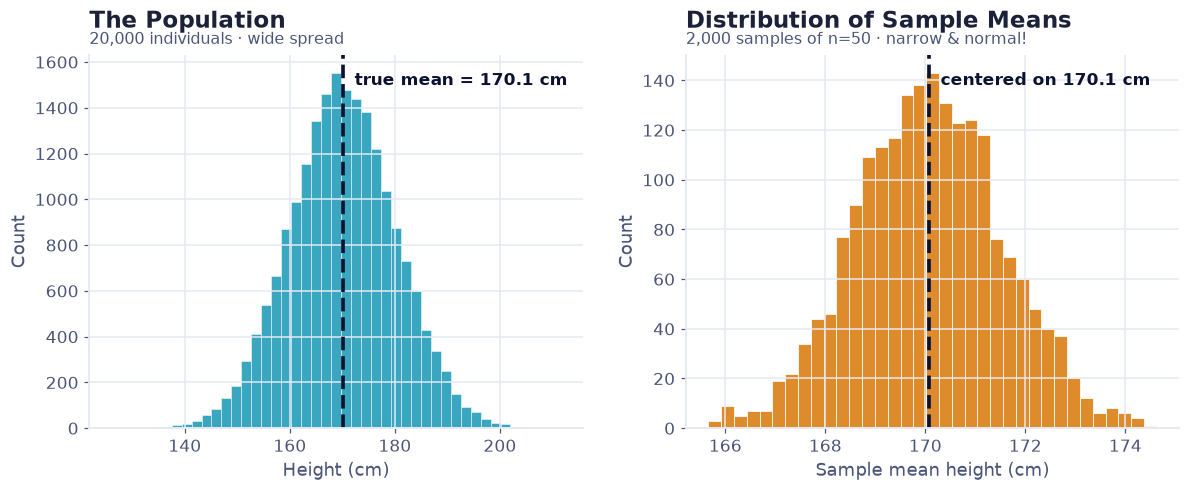

Population mean      : 170.07 cm
Mean of sample means : 170.07 cm   <- almost identical!
Std of sample means  : 1.46 cm   (the "standard error")
Theory (10/sqrt(50)) : 1.41 cm


In [5]:
# A "population" of 20,000 adult heights (cm) we pretend we cannot fully measure
population = rng.normal(170, 10, 20_000)
true_mean = population.mean()

# Take 2,000 independent samples of 50 people each; record each sample mean
sample_means = np.array([rng.choice(population, size=50, replace=False).mean()
                         for _ in range(2000)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,4.6))

# Left: the population
ax1.hist(population, bins=45, color=CYAN, alpha=0.8, edgecolor="white", linewidth=0.4)
ax1.axvline(true_mean, color=NAVY, linewidth=2.4, linestyle="--")
ax1.text(true_mean, ax1.get_ylim()[1]*0.92, f"  true mean = {true_mean:.1f} cm",
         fontweight="bold", color=NAVY)
titlecard(ax1, "The Population", "20,000 individuals · wide spread")
ax1.set_xlabel("Height (cm)"); ax1.set_ylabel("Count")

# Right: distribution of the 2,000 sample means
ax2.hist(sample_means, bins=35, color=AMBER, alpha=0.85, edgecolor="white", linewidth=0.6)
ax2.axvline(true_mean, color=NAVY, linewidth=2.4, linestyle="--")
ax2.text(true_mean, ax2.get_ylim()[1]*0.92, f"  centered on {true_mean:.1f} cm",
         fontweight="bold", color=NAVY)
titlecard(ax2, "Distribution of Sample Means", "2,000 samples of n=50 · narrow & normal!")
ax2.set_xlabel("Sample mean height (cm)"); ax2.set_ylabel("Count")

plt.tight_layout(); plt.show()

print(f"Population mean      : {true_mean:.2f} cm")
print(f"Mean of sample means : {sample_means.mean():.2f} cm   <- almost identical!")
print(f"Std of sample means  : {sample_means.std():.2f} cm   (the \"standard error\")")
print(f"Theory (10/sqrt(50)) : {10/np.sqrt(50):.2f} cm")

**The big idea:** even though individual heights vary a lot (left), the *average* of a 50-person sample is a remarkably reliable estimate of the true population mean (right). This is why a poll of 1,000 people can speak about millions — and it is exactly the principle behind **train/test splits** and **bootstrapping** in machine learning.

<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 4 · LAW OF LARGE NUMBERS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🎲 More data → less uncertainty</div>
<div style="color:#4a5578;margin-top:6px">As we collect more observations, our estimate settles down toward the truth. Watch the running average of dice rolls converge to the true mean of 3.5.</div>
</div>

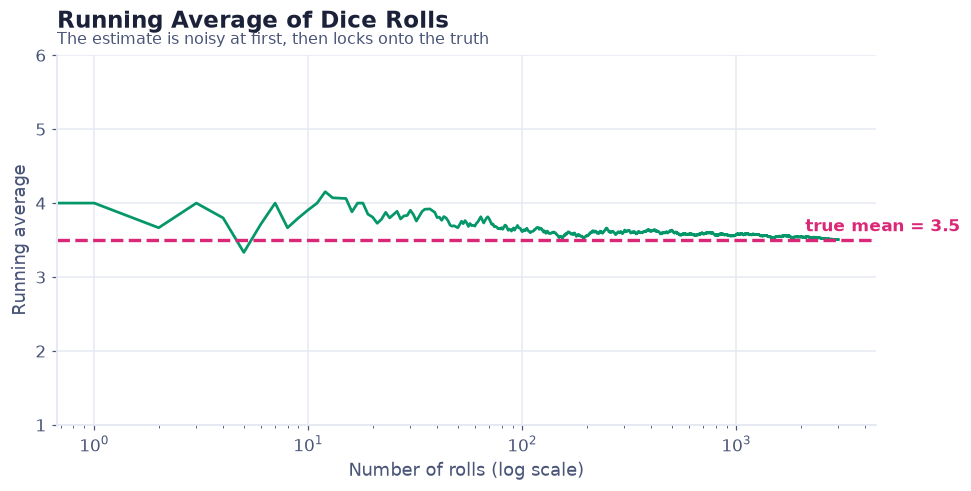

After 10 rolls   : 3.800
After 100 rolls  : 3.630
After 3000 rolls : 3.507


In [6]:
rolls = rng.integers(1, 7, size=3000)          # 3,000 fair-die rolls
running_mean = np.cumsum(rolls) / np.arange(1, len(rolls)+1)
true_value = 3.5

fig, ax = plt.subplots(figsize=(9,4.6))
ax.plot(running_mean, color=GREEN, linewidth=1.8)
ax.axhline(true_value, color=PINK, linewidth=2.2, linestyle="--")
ax.text(len(rolls)*0.7, true_value+0.12, "true mean = 3.5",
        color=PINK, fontweight="bold")
ax.set_xscale("log")
titlecard(ax, "Running Average of Dice Rolls",
          "The estimate is noisy at first, then locks onto the truth")
ax.set_xlabel("Number of rolls (log scale)"); ax.set_ylabel("Running average")
ax.set_ylim(1, 6)
plt.tight_layout(); plt.show()

print(f"After 10 rolls   : {running_mean[9]:.3f}")
print(f"After 100 rolls  : {running_mean[99]:.3f}")
print(f"After 3000 rolls : {running_mean[-1]:.3f}")

<div style="background:linear-gradient(135deg,#0a1230,#19134a);border-radius:12px;padding:18px 22px;color:#fff;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#00d4ff;letter-spacing:1px">DEMO 5 · STATISTICS → MACHINE LEARNING</span>
<div style="font-size:22px;font-weight:800;margin-top:4px">🤖 A regression line <i>is</i> a machine-learning model</div>
<div style="color:#b9c2e0;margin-top:6px">We fit a least-squares line to predict salary from years of experience. Least squares is a 200-year-old statistical method — and simultaneously one of the most-used ML models on earth.</div>
</div>

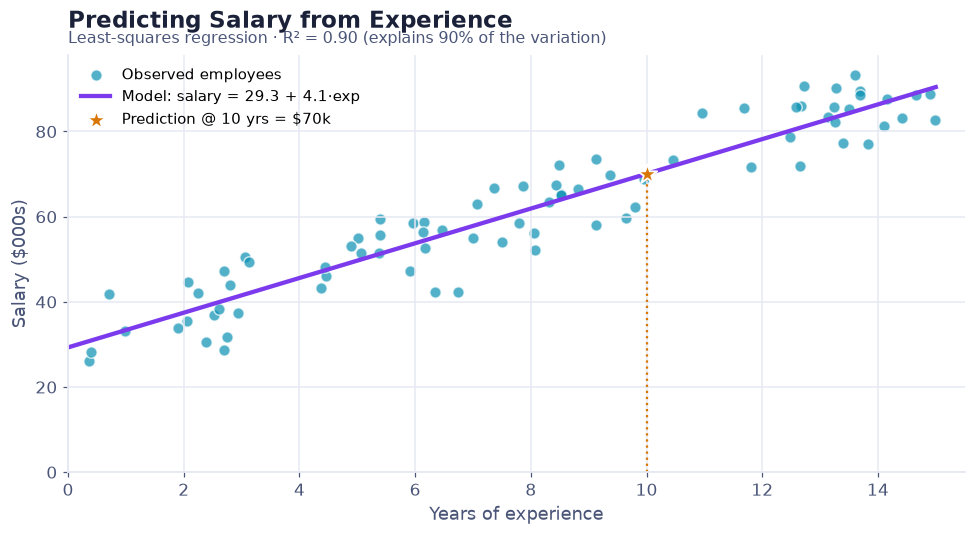

Learned model : salary = 29.29 + 4.08 * experience
R-squared     : 0.898
Prediction    : a 10-year employee earns about $70k


In [7]:
# Generate data: salary tends to rise with experience (+ real-world noise)
experience = rng.uniform(0, 15, 80)
salary = 30 + 4.2*experience + rng.normal(0, 6, 80)   # $000s

# --- Fit a least-squares line: the core statistical/ML step ---
slope, intercept = np.polyfit(experience, salary, deg=1)
pred = slope*experience + intercept

# R^2 — how much variation the model explains (a statistics metric used everywhere in ML)
ss_res = np.sum((salary - pred)**2)
ss_tot = np.sum((salary - salary.mean())**2)
r2 = 1 - ss_res/ss_tot

# Predict for a new, unseen employee with 10 years experience
new_x = 10
new_pred = slope*new_x + intercept

fig, ax = plt.subplots(figsize=(9,5))
ax.scatter(experience, salary, color=CYAN, s=55, alpha=0.7,
           edgecolor="white", linewidth=1, label="Observed employees")
xs = np.linspace(0, 15, 100)
ax.plot(xs, slope*xs+intercept, color=PURPLE, linewidth=2.8,
        label=f"Model: salary = {intercept:.1f} + {slope:.1f}·exp")

# Highlight a prediction
ax.scatter([new_x], [new_pred], color=AMBER, s=180, zorder=5, marker="*",
           edgecolor="white", linewidth=1.2, label=f"Prediction @ 10 yrs = ${new_pred:.0f}k")
ax.plot([new_x,new_x],[0,new_pred], color=AMBER, linestyle=":", linewidth=1.5)

titlecard(ax, "Predicting Salary from Experience",
          f"Least-squares regression · R² = {r2:.2f} (explains {r2*100:.0f}% of the variation)")
ax.set_xlabel("Years of experience"); ax.set_ylabel("Salary ($000s)")
ax.set_xlim(0,15.5); ax.set_ylim(bottom=0)
ax.legend(loc="upper left", fontsize=9.5)
plt.tight_layout(); plt.show()

print(f"Learned model : salary = {intercept:.2f} + {slope:.2f} * experience")
print(f"R-squared     : {r2:.3f}")
print(f"Prediction    : a 10-year employee earns about ${new_pred:.0f}k")

**Why this is the punchline of the chapter:** what we just did has two names.

- A **statistician** calls it *linear regression* — estimating parameters and explaining variance (R²).
- An **ML engineer** calls it *training a model* — learning weights from data to predict unseen cases.

They are the **same thing**. Scale this idea up — more features, more data, nonlinear functions, millions of parameters — and you arrive at modern machine learning and AI. The statistics never left; it just got bigger.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li><b>Descriptive statistics</b> summarized our exam scores (center &amp; spread).</li>
<li>The <b>normal distribution</b> and 68–95–99.7 rule describe how data clusters.</li>
<li><b>Inferential statistics</b> + the <b>Central Limit Theorem</b> let a small sample speak for a whole population.</li>
<li>The <b>Law of Large Numbers</b> showed why more data means more certainty.</li>
<li>A <b>least-squares regression</b> revealed that statistics <i>is</i> the engine inside machine learning.</li>
</ul>
<div style="margin-top:14px;padding-top:14px;border-top:1px dashed #e6e9f2;color:#7c3aed;font-weight:700">
🔖 Head back to the book to continue where you left off — try the challenges and quiz next.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>